In [1]:
# NOTE: unfortunately depends_on_optional machinery in a submodule prevents autoreload from working for that submodule
%load_ext autoreload
%autoreload 2

In [1]:
#import pyproj
#pyproj_dir = '/home/sbhusha1/.conda/envs/coincident/lib/python3.13/site-packages/pyproj/proj_dir/share/proj'

#pyproj.datadir.set_data_dir(pyproj_dir)

import common_functions
import os,glob
import scipy
import pandas as pd
# TODO: consider moving some pieces into coincident library
import cql2
import numpy as np
from rasterstats import point_query, zonal_stats
from affine import Affine
import pyproj
import rasterio
import xarray as xr
from osgeo import gdal
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt
import sliderule
import coincident
from coincident import pcd_fixtures
from sliderule import earthdata, icesat2, gedi

/panfs/ccds02/nobackup/people/sbhusha1/sw/coincident/src/coincident/io/download.py:28: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/panfs/ccds02/nobackup/people/sbhusha1/sw/coincident/src/coincident/search/main.py:15: UserWarning: Unable to authenticate with Maxar API. Please set MAXAR_API_KEY environment variable.
  from coincident.search import neon_api, opentopo_api, stac, wesm


In [2]:
## Functions
def load_stv_product_local(href, overview_level=None):
    if overview_level is not None:
        da = xr.open_dataarray(
            href,
            engine="rasterio",
            mask_and_scale=True,
            backend_kwargs={"open_kwargs": {"overview_level": overview_level}},
        ).squeeze()
    else:
        da = xr.open_dataarray(
            href,
            engine="rasterio",
            mask_and_scale=True,
        ).squeeze()
    return da

def compute_gedi_surface(row):
    rh_array = np.fromstring(row['rh'].strip('[]'), sep=' ')
    output = row['elevation_lm']+rh_array[-1]
    return output

def compute_gedi_surface(row):
    rh_array = np.fromstring(row['rh'].strip('[]'), sep=' ')
    output = row['elevation_lm']+rh_array[-1]
    return output

In [3]:
gf_is2_stac = gpd.read_file('/home/sbhusha1/notebooks/pcd/20250718_PCD_neon_is2_tracks.geojson')
workunits = np.unique(gf_is2_stac.neon_id)

In [4]:
def da_to_rasterstats_inputs(da):
    """
    Extract numpy array, affine transform, and nodata
    from an xarray DataArray for use with rasterstats.

    Parameters
    ----------
    da : xarray.DataArray
        2D array with dimensions (y, x).

    Returns
    -------
    data : np.ndarray
    affine : Affine
    nodata : float or None
    """
    data = da.values

    x = da.x.values
    y = da.y.values
    res_x = float(x[1] - x[0])
    res_y = float(y[1] - y[0])  # typically negative for top-down rasters

    # Affine: upper-left corner of the upper-left pixel
    affine = Affine(res_x, 0, x[0] - res_x / 2,
                    0, res_y, y[0] - res_y / 2)

    nodata = None
    if hasattr(da, "rio") and da.rio.nodata is not None:
        nodata = da.rio.nodata
    elif "_FillValue" in da.attrs:
        nodata = da.attrs["_FillValue"]
    elif "_FillValue" in da.encoding:
        nodata = da.encoding["_FillValue"]

    return data, affine, nodata



def sample_windowed_stats(da, gdf, window_radius=12.5,
                          stats=["mean", "median", "std", "min", "max", "count"]):
    """
    Zonal statistics within a circular buffer around each point
    to mimic GEDI footprint.

    Parameters
    ----------
    da : xarray.DataArray
    gdf : GeoDataFrame
    window_radius : float
        Radius in same units as da coordinates (e.g., 12.5 m for 25 m diameter GEDI footprint).
    stats : list of str
        rasterstats stat names.

    Returns
    -------
    dict of np.ndarrays
    """
    data, affine, nodata = da_to_rasterstats_inputs(da)

    gdf_buf = gdf.copy()
    gdf_buf["geometry"] = gdf_buf.geometry.buffer(window_radius)  # circular by default

    zs = zonal_stats(
        gdf_buf,
        data,
        affine=affine,
        nodata=nodata,
        stats=stats,
    )

    return {s: np.array([z[s] for z in zs], dtype=float) for s in stats}


def sample_dem_at_points(
    da_dem: xr.DataArray,
    gdf_points: gpd.GeoDataFrame,
    sampling_method: str = 'bilinear',
    diff_col: str | None = None,
) -> pd.DataFrame:
    """
    Sample DEM at point locations from GeoDataFrame using Xarray Advanced Interpolation (bilinear interpolation)
    If the GeoDataFrame column name is provided (e.g. h_li for IS2 ATL06), also calculate
    difference by subtracting the sampled raster elevation.

    Parameters
    ----------
    da_dem: xr.DataArray
        DEM as xarray DataArray with only 'x' and 'y' spatial dimensions
    gdf_points: gpd.GeoDataFrame
        GeoDataFrame with point geometries to sample DEM at
    sample_method: str
        sampling method, defaualt is bilinear interpolation. If max or median, will give maximum return within a 25 m footprint (mimicing GEDI). Max should be used for canopy, comparison, while median for ground measurements.
    diff_col: Optional[str]
        Column in GeoDataFrame to difference [gdf_points[diff_col] - DEM]

    Returns
    -------
    gpd.pd.GeoDataFrame
        GeoDataFrame with sampled DEM elevations and optional 'elev_diff' column
    """
    assert isinstance(da_dem, xr.DataArray), "da_dem must be an xarray.DataArray"
    da_points = gdf_points.get_coordinates().to_xarray()
    # Ensure we don't return a multi-index
    da_dem = da_dem.squeeze()
    if sampling_method == 'bilinear':
        samples = (
            da_dem.drop_vars(["band", "spatial_ref"])
            .interp(da_points)
            .to_dataframe(name="dem_elevation")
        )
    else:
        output = sample_windowed_stats(da_dem,gdf_points,window_radius=12.5,stats=[sampling_method])[sampling_method]
        samples = gdf_points.get_coordinates()
        samples['dem_elevation'] = output
    if diff_col is not None:
        samples[diff_col] = gdf_points[diff_col].to_numpy()
        samples["elev_diff"] = (
            gdf_points[diff_col].to_numpy() - samples["dem_elevation"]
        )

    return samples

In [5]:
%cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_first_product_delivery_sep17_25/usgs_pcd_products/


/panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_first_product_delivery_sep17_25/usgs_pcd_products


In [6]:
def perform_comparison(workunit,gdf_fn,lidar_dtm_da,suptit,clim):
    gedi_gdf = gpd.read_file(gdf_fn)
    gedi_gdf_reproj = gedi_gdf.to_crs(lidar_dtm_da.rio.crs)
    gedi_gdf_reproj[gedi_column] = gedi_gdf_reproj.apply(compute_gedi_surface,axis=1)

    output_bilinear_ground = sample_dem_at_points(lidar_dtm_da,gedi_gdf_reproj,sampling_method='bilinear',diff_col='elevation_lm')
    median_ground_sample_output = sample_dem_at_points(lidar_dtm_da,gedi_gdf_reproj,sampling_method='median',diff_col='elevation_lm') 

    f,ax = plt.subplots(1,2,figsize=(10,10))
    val_array = output_bilinear_ground['elev_diff'].values
    val_array = val_array[~np.isnan(val_array)]
    med = np.median(val_array)
    nmad = scipy.stats.median_abs_deviation(val_array)*1.4826
    ax[0].hist(val_array,bins=300)
    ax[0].set_xlim(clim[0],clim[1])
    ax[0].set_xlabel('Elevation difference (m)')
    ax[0].set_ylabel('Num points')
    title_stats = f"\nMED: {med:.2f}m, NMAD: {nmad:.2f}m"
    ax[0].set_title('GEDI footprint elevation vs ALS DTM bilinear at exact GEDI point location'+title_stats)

    val_array = median_ground_sample_output['elev_diff'].values
    val_array = val_array[~np.isnan(val_array)]
    med = np.median(val_array)
    nmad = scipy.stats.median_abs_deviation(val_array)*1.4826
    ax[1].hist(val_array,bins=300)
    ax[1].set_xlim(clim[0],clim[1])
    ax[1].set_xlabel('Elevation difference (m)')
    ax[1].set_ylabel('Num points')
    title_stats = f"\nMED: {med:.2f}m, NMAD: {nmad:.2f}m"
    ax[1].set_title('GEDI footprint elevation vs ALS DTM median at GEDI footprint'+title_stats)
    
    f.suptitle(f'{workunit}_{suptit}')
    plt.tight_layout()
    

In [7]:
def workunit_check(workunit,clim=(-10,10)):
    lidar_dtm_fn = sorted(glob.glob(f'{workunit}*_processing/*DTM_fill_window_size_4_mos.tif'))[0] 
    gedi_gdf_postcoreg_fn = sorted(glob.glob(f'/panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_usgs_lpc_proc_total_bounds/delivery_version2/{workunit}*_processing_98_percentile/GEDI_aligned_product_*.gpkg'))[0]
                
    gedi_gdf_precoreg_fn = sorted(glob.glob(f'/panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_usgs_lpc_proc_total_bounds/delivery_version2/{workunit}*_processing_98_percentile/GEDI_original_product_*.gpkg'))[0]
    lidar_dtm_da = load_stv_product_local(lidar_dtm_fn)  
    perform_comparison(workunit,gedi_gdf_precoreg_fn,lidar_dtm_da,'pre-coreg',clim)

    perform_comparison(workunit,gedi_gdf_postcoreg_fn,lidar_dtm_da,'post-coreg',clim)

In [8]:
gf_is2_stac = gpd.read_file('/home/sbhusha1/notebooks/pcd/20250709_PCD_3dep_is2_tracks.geojson')
workunits = np.unique(gf_is2_stac.usgs_workunit)

In [9]:
workunits

array(['AZ_PimaCo_2_2021', 'CA_SanFrancisco_1_B23', 'CA_YosemiteNP_2019',
       'CO_WestCentral_2019', 'GA_Central_3_2019',
       'NE_Northeast_Phase2_2_2020', 'TX_DesertMountains_B1_2018',
       'WI_Brown_2_2020', 'WY_FEMA_East_B9_2019'], dtype=object)

In [10]:
gedi_column='elevation_100_perc'

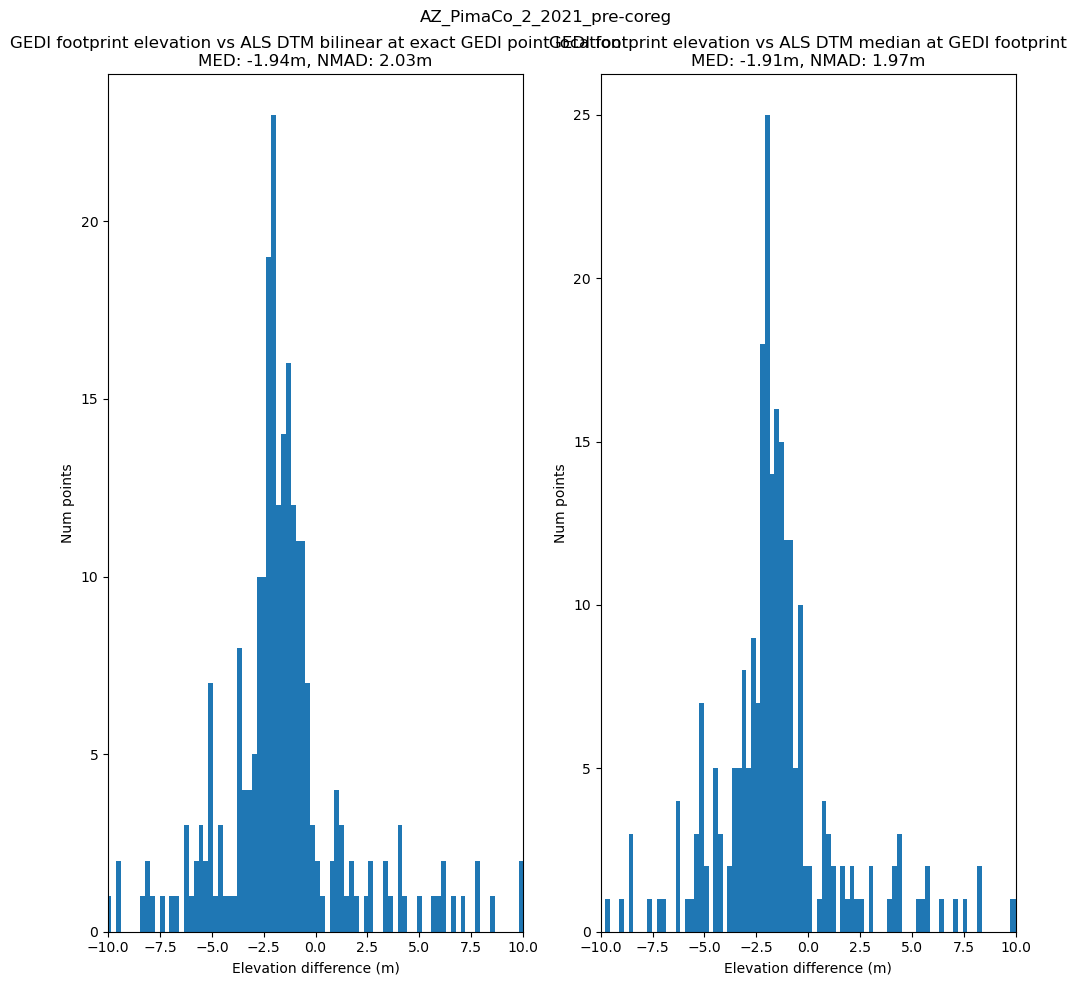

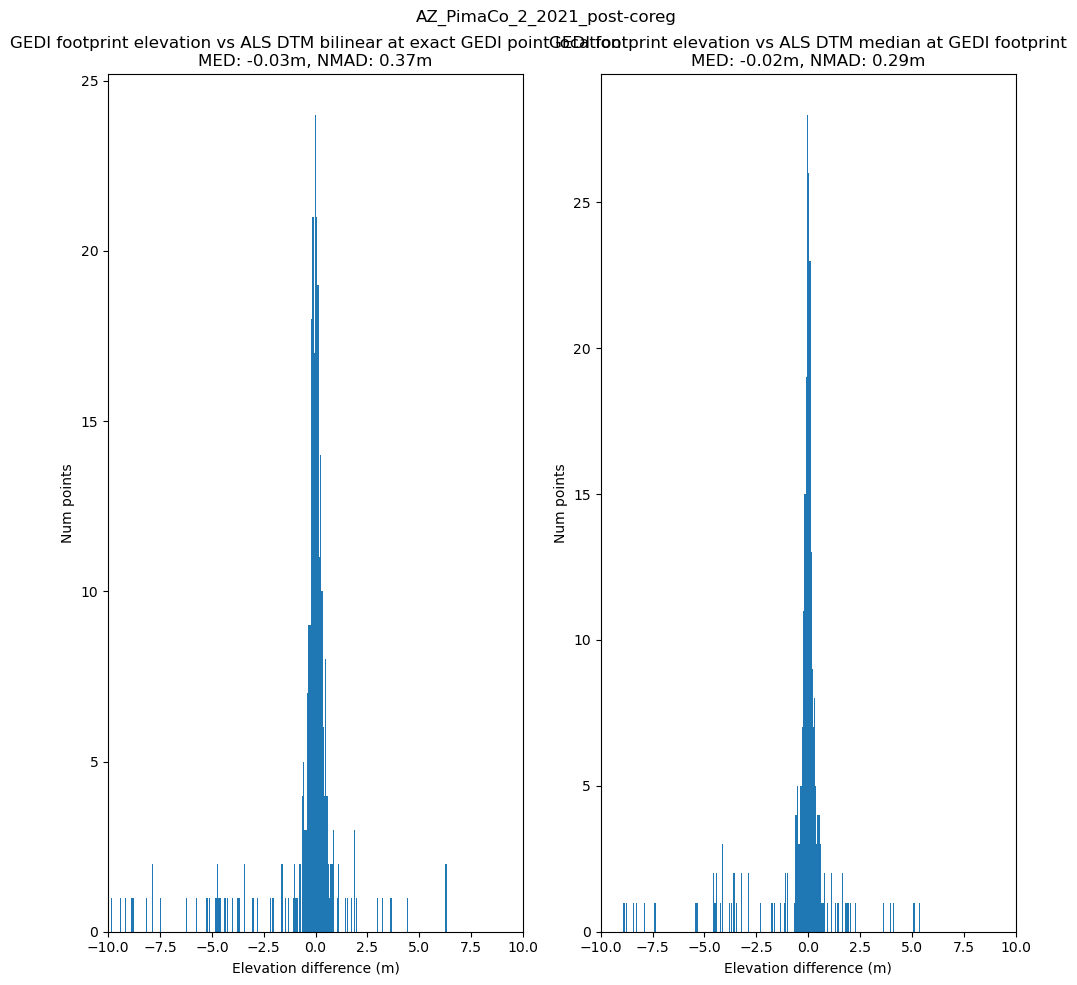

In [11]:
workunit_check(workunits[0])

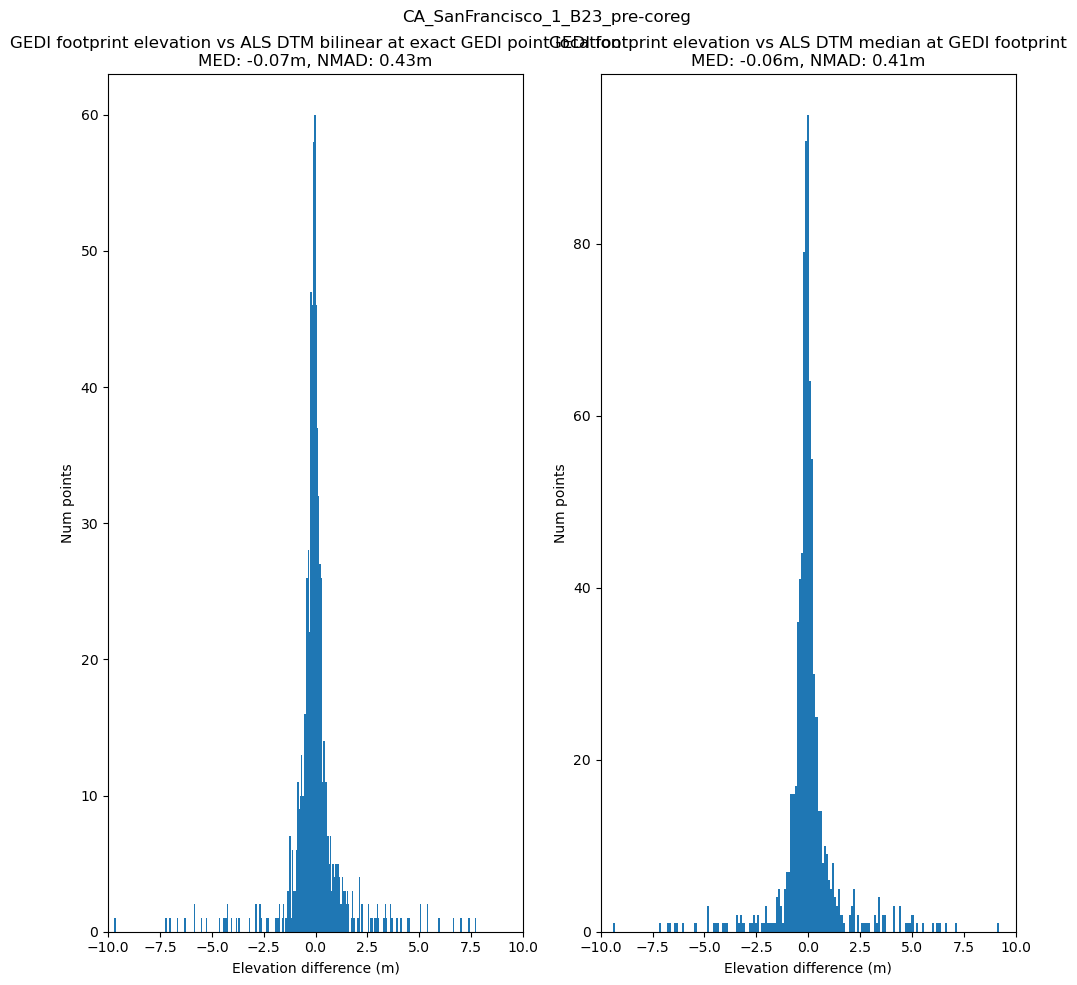

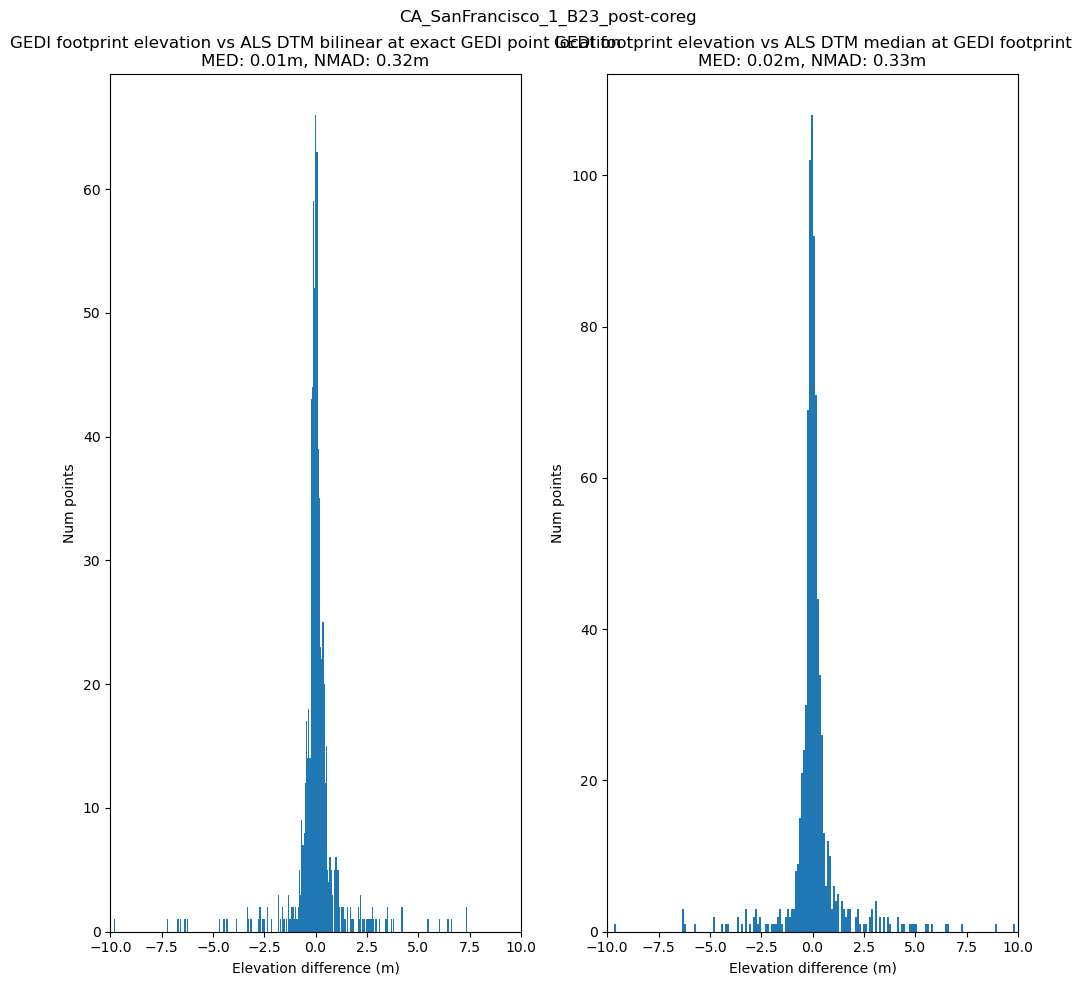

In [45]:
workunit_check(workunits[1])

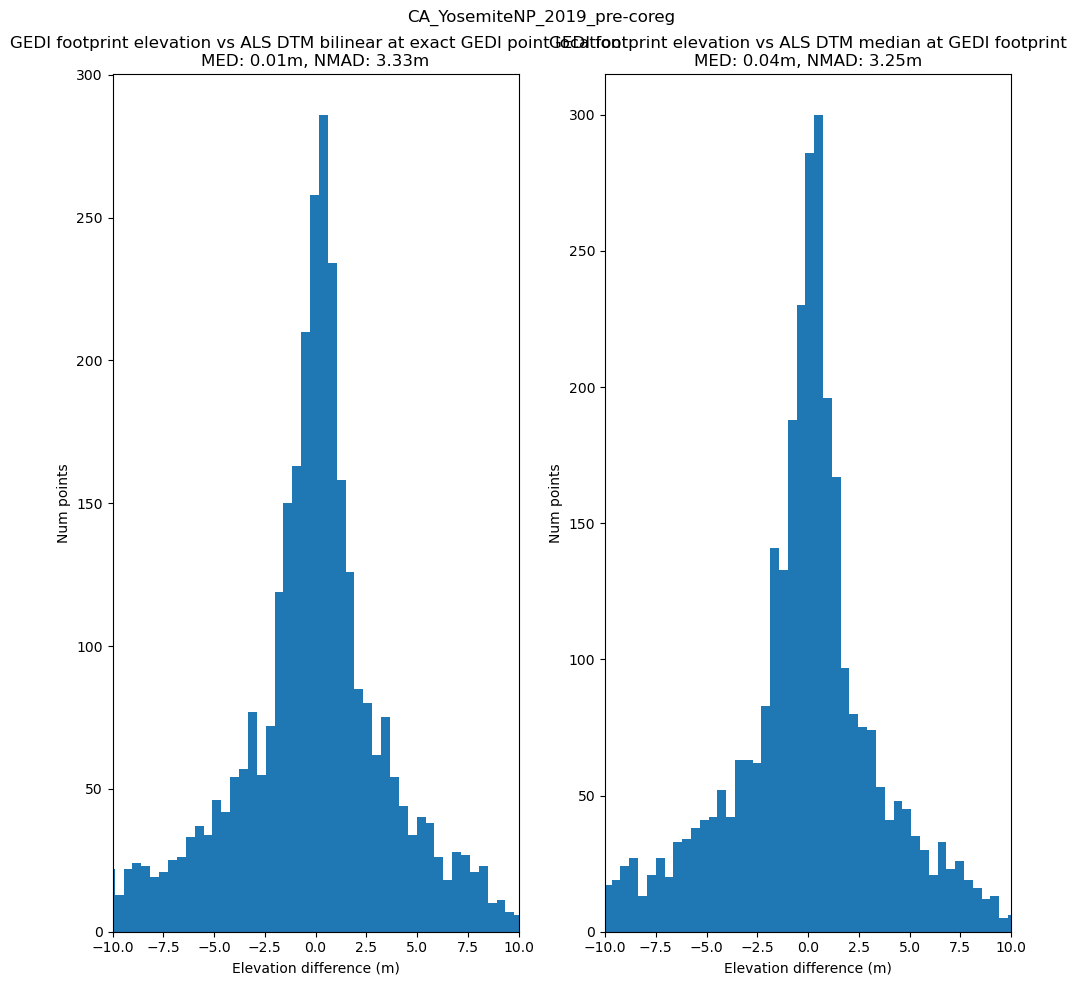

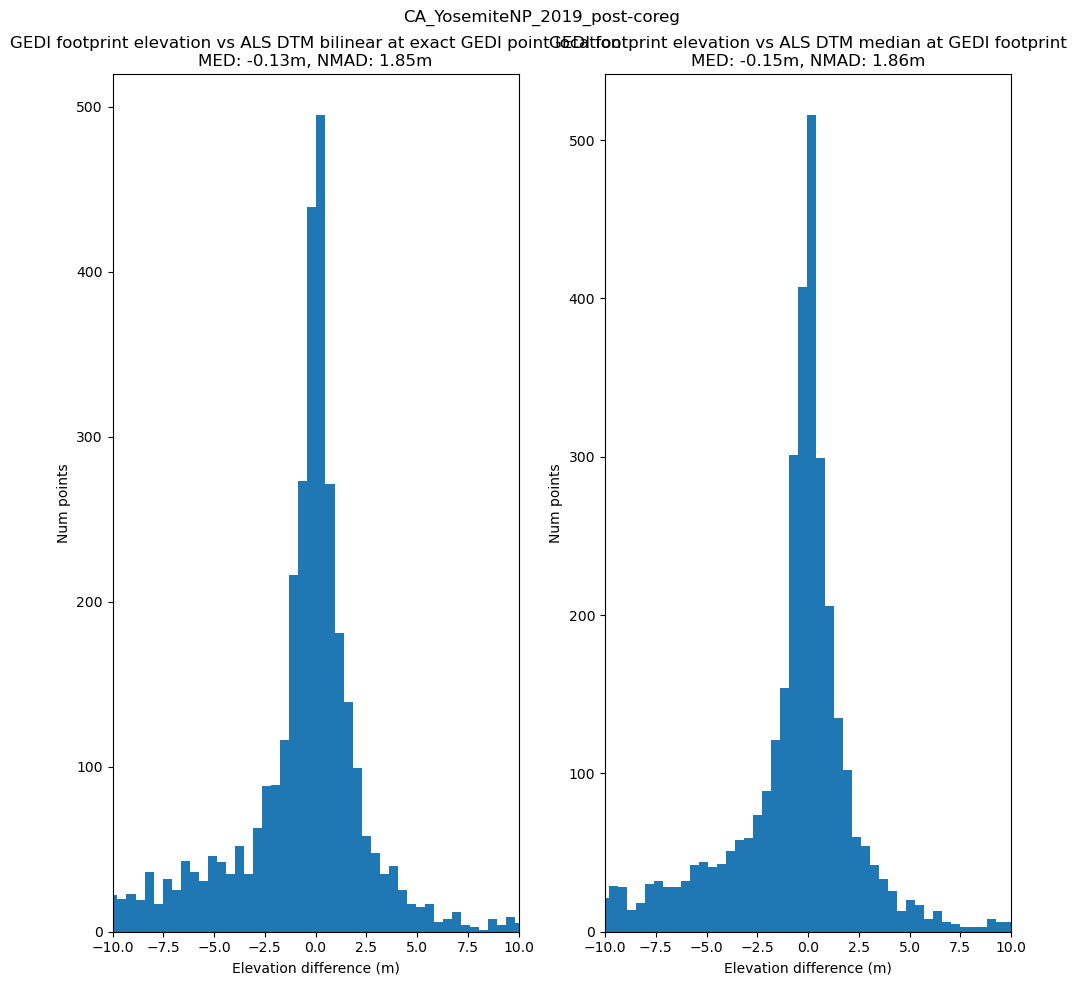

In [46]:
workunit_check(workunits[2])

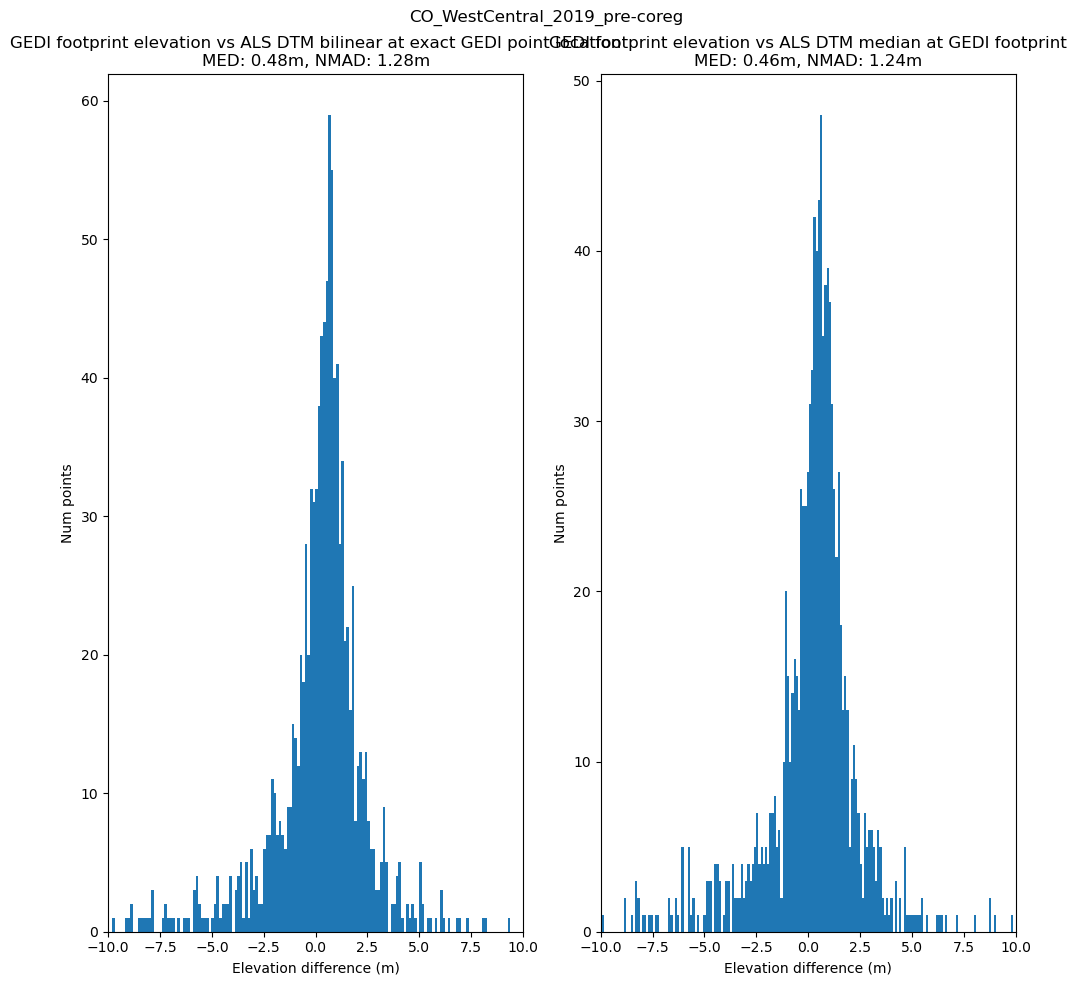

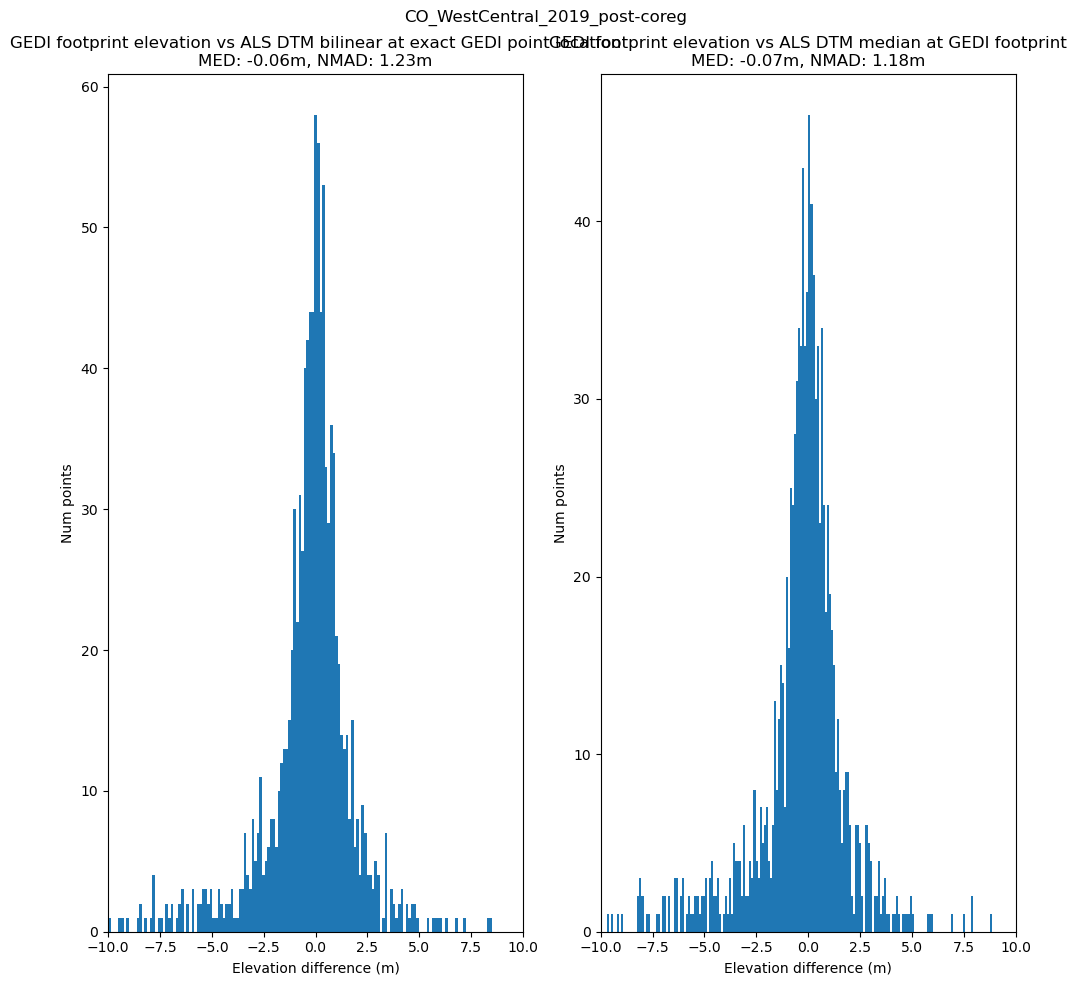

In [47]:
workunit_check(workunits[3])

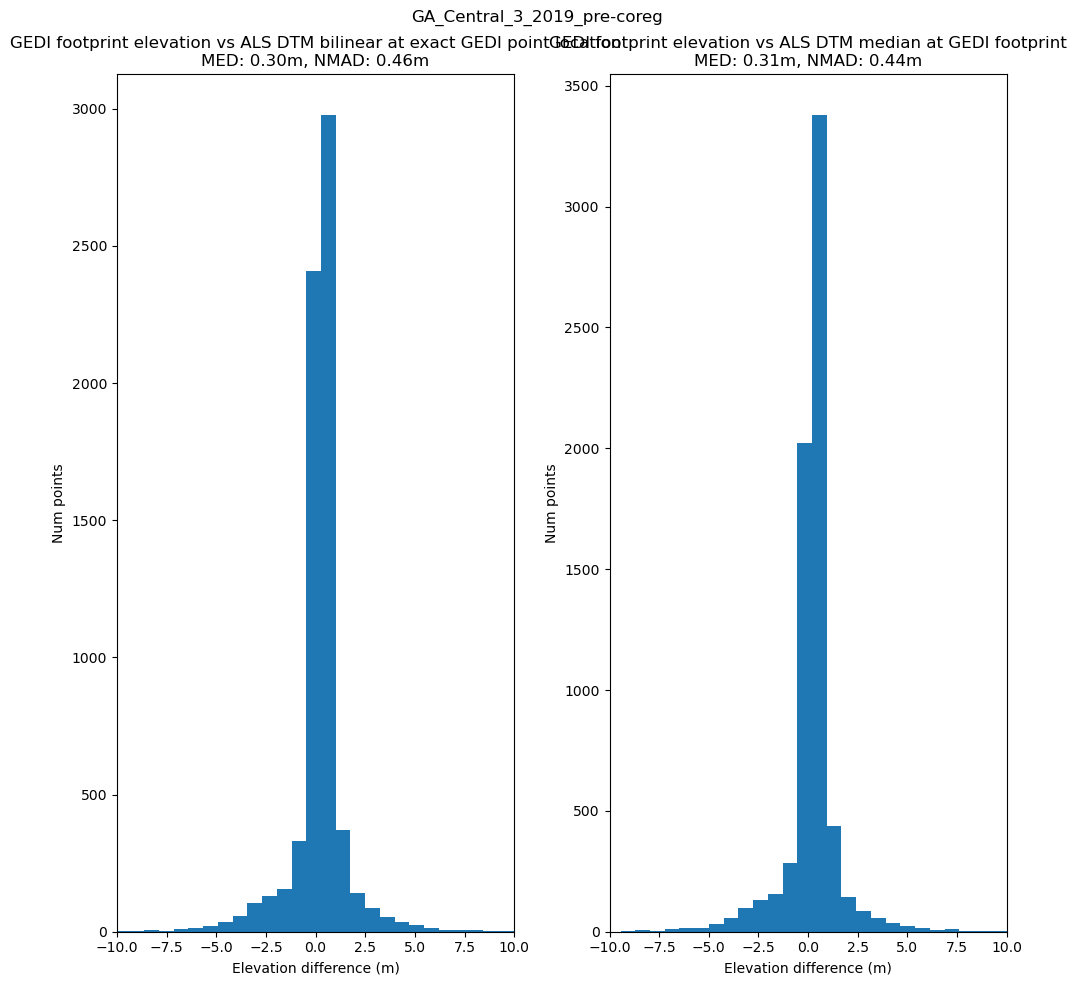

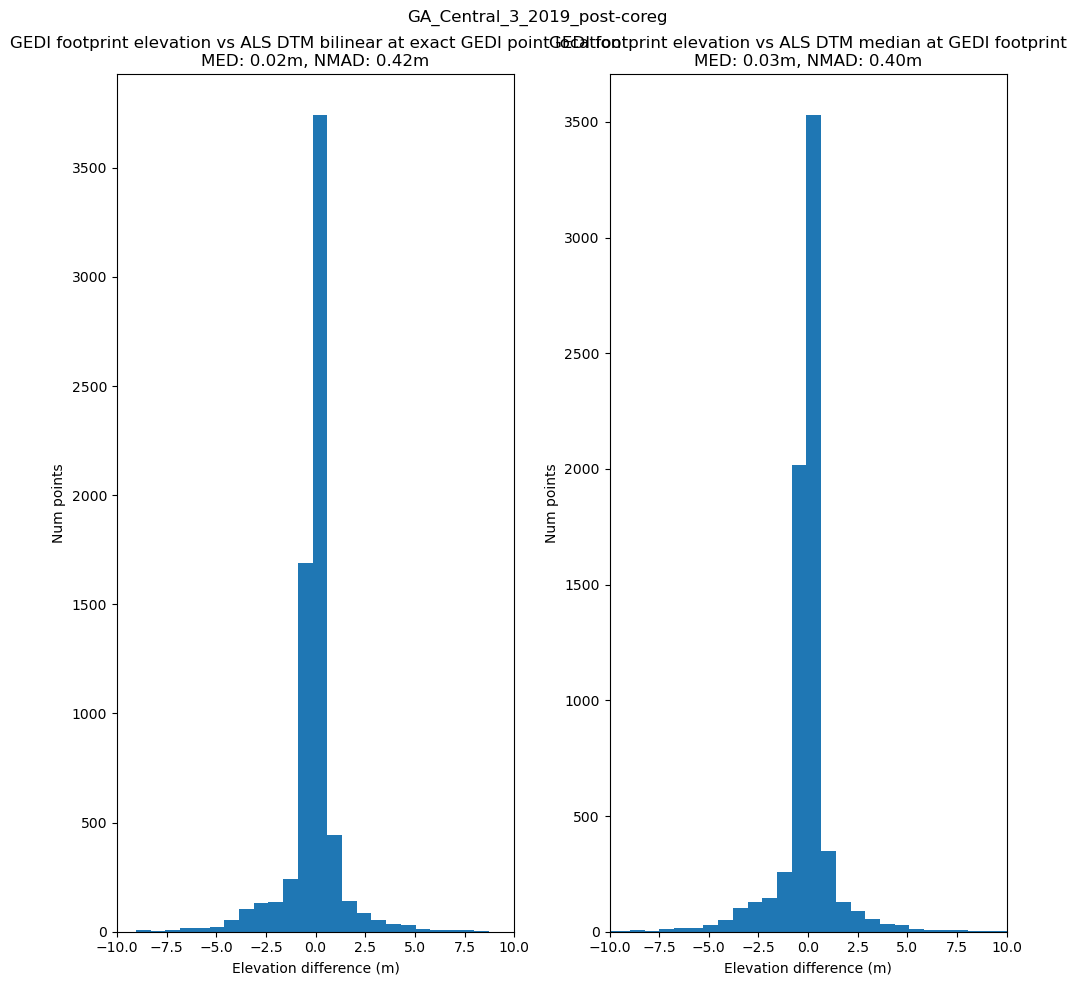

In [49]:
workunit_check(workunits[4])

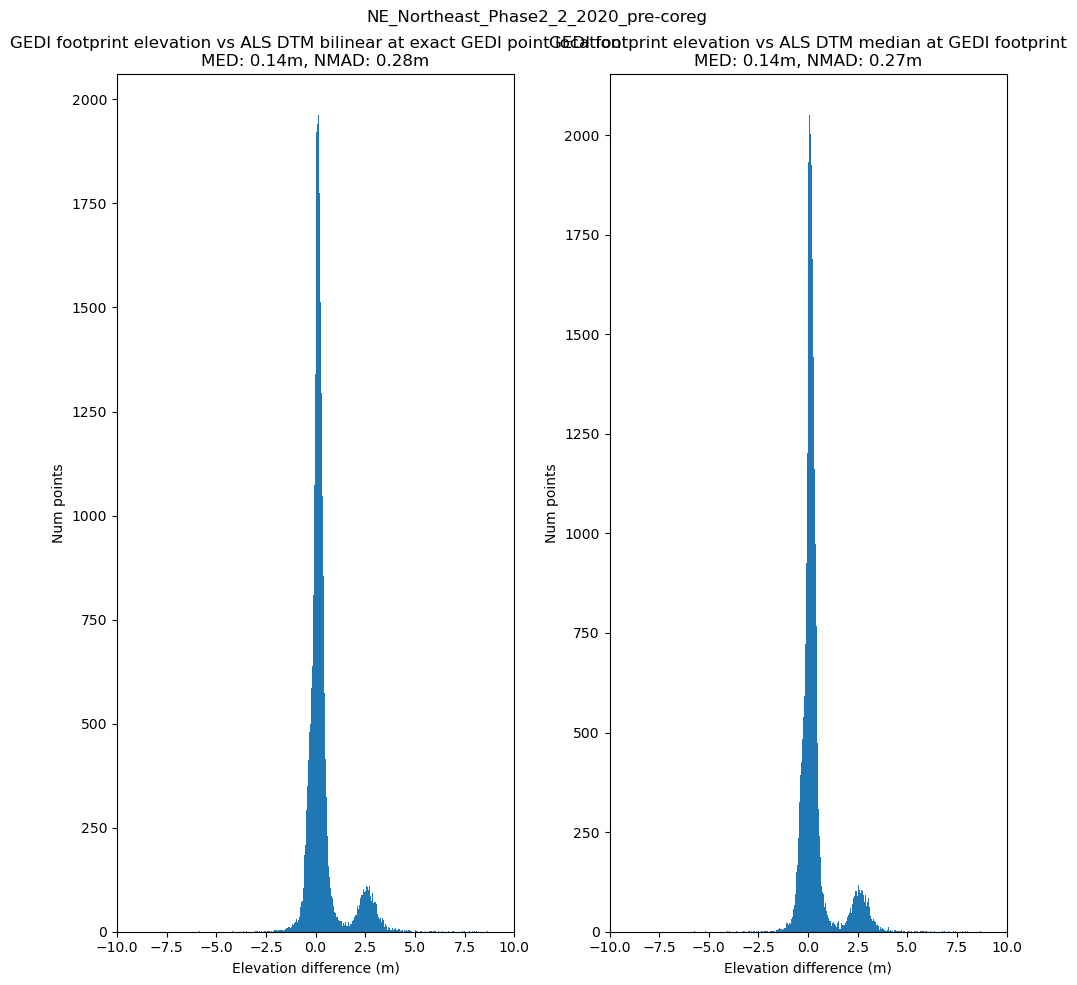

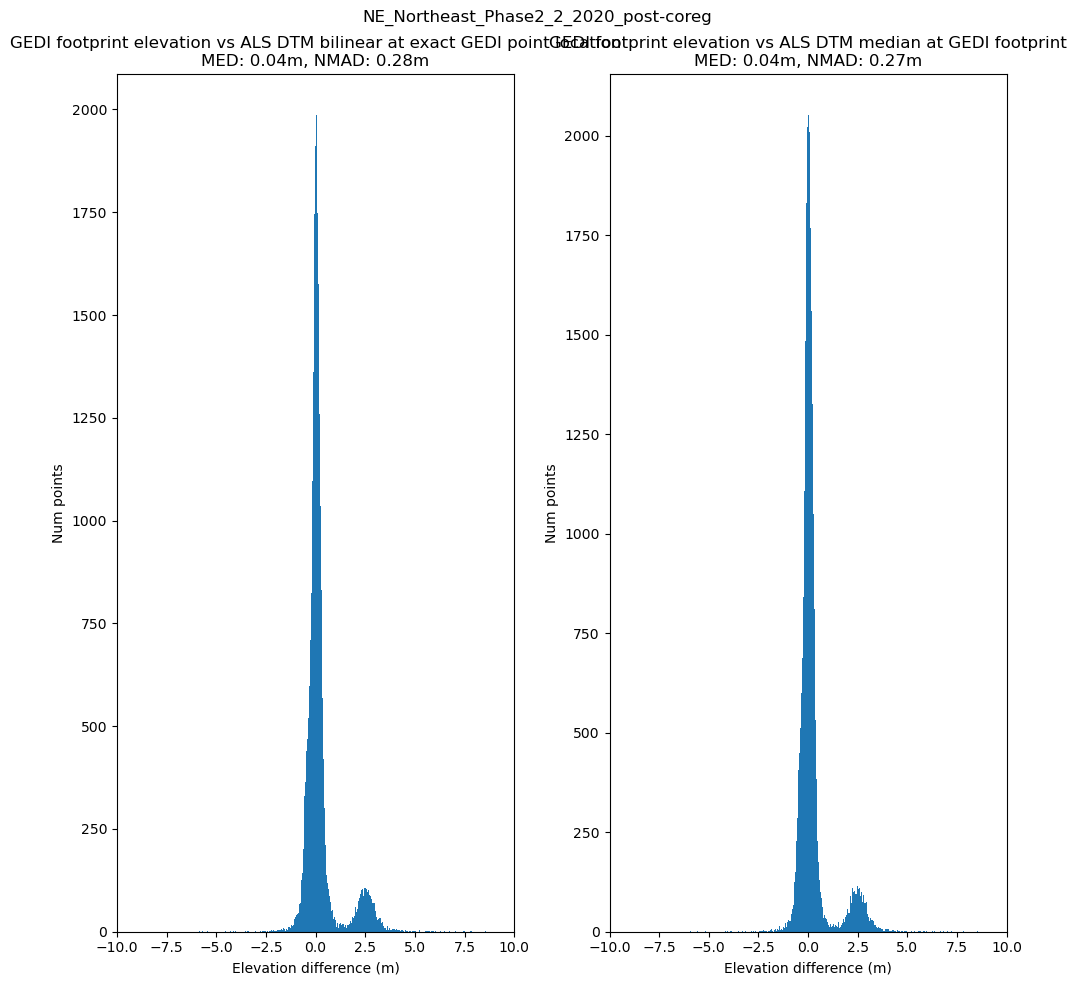

In [50]:
workunit_check(workunits[5])

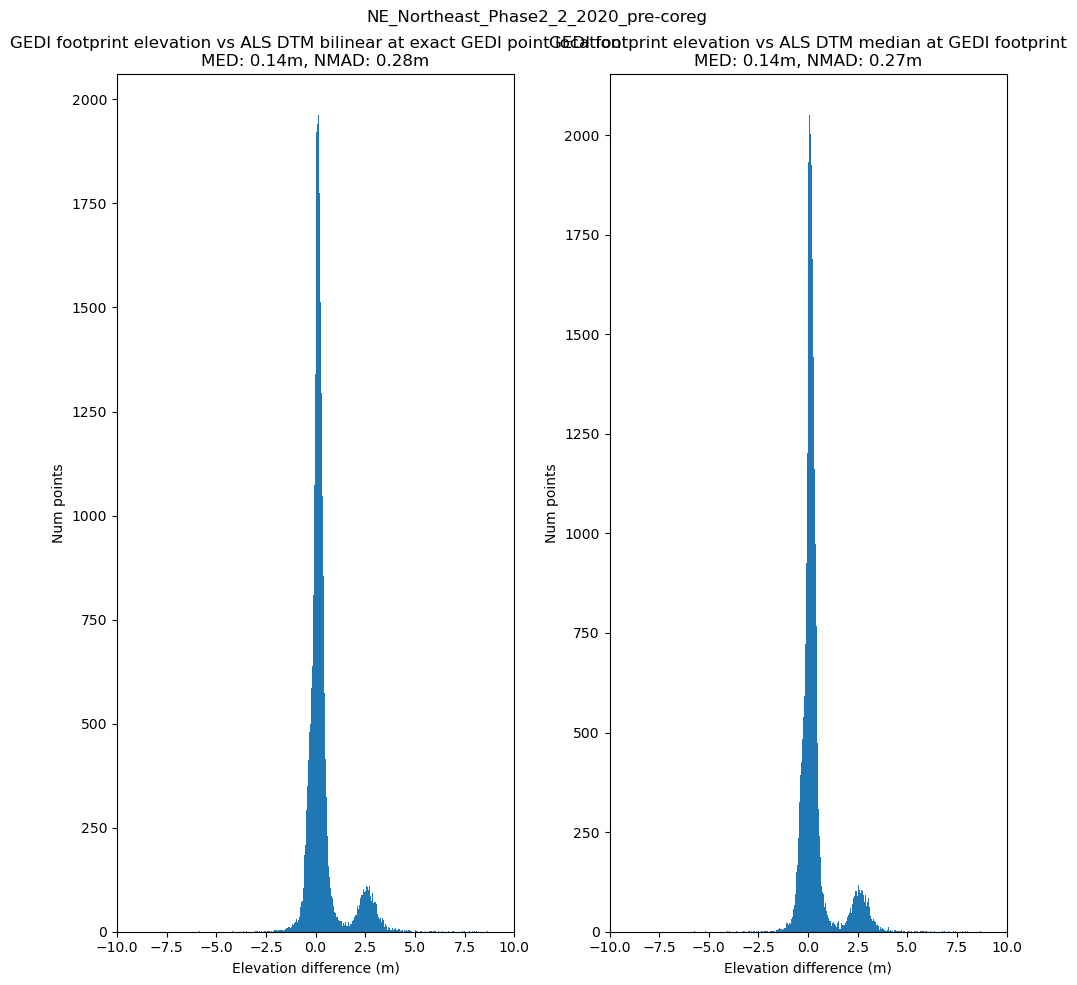

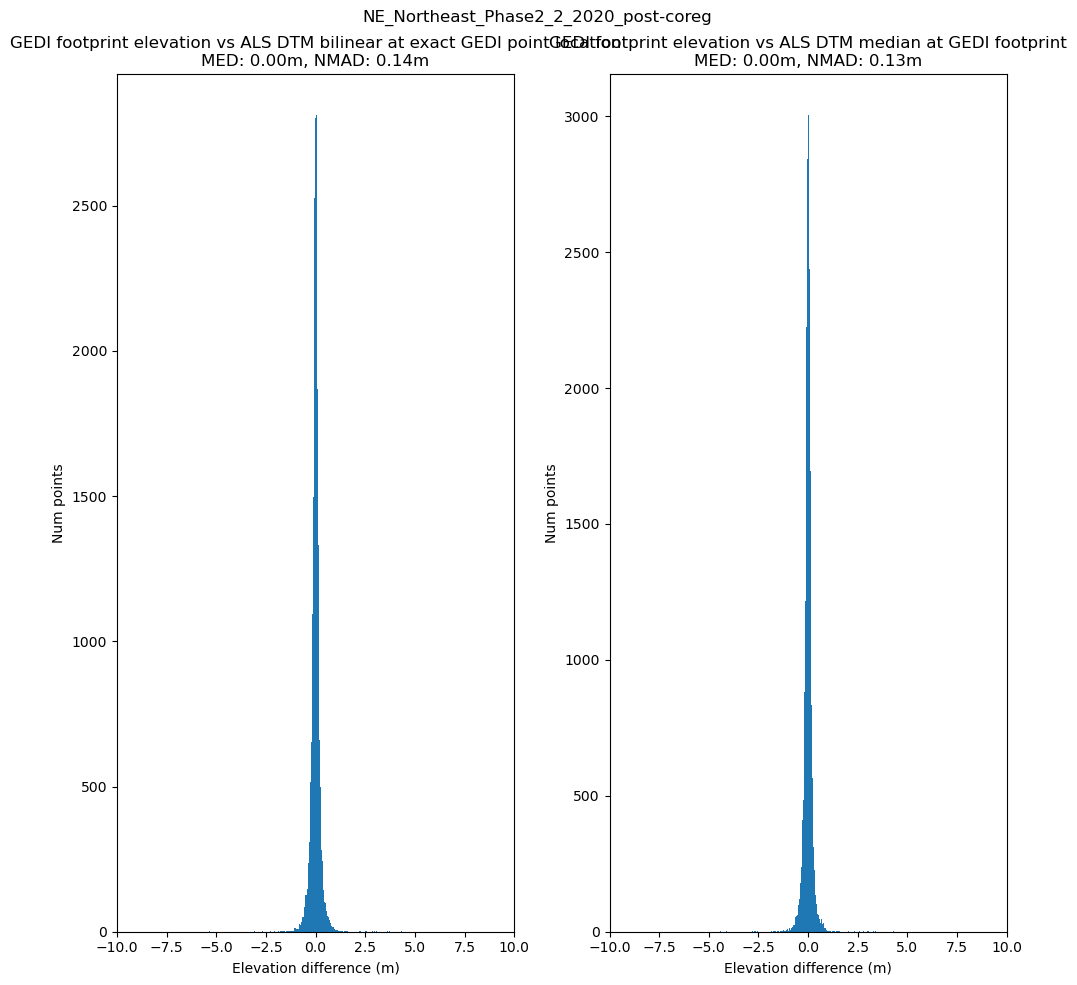

In [54]:
workunit_check(workunits[5])

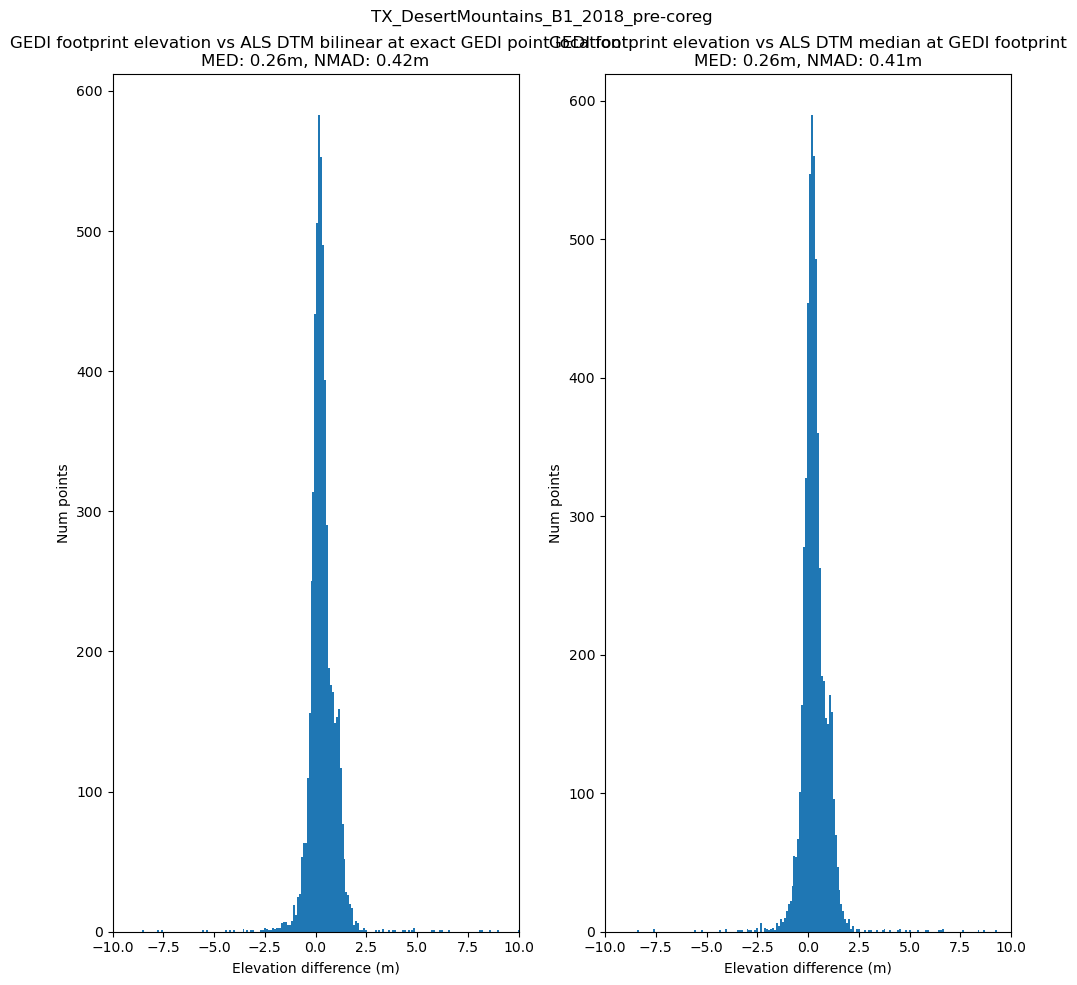

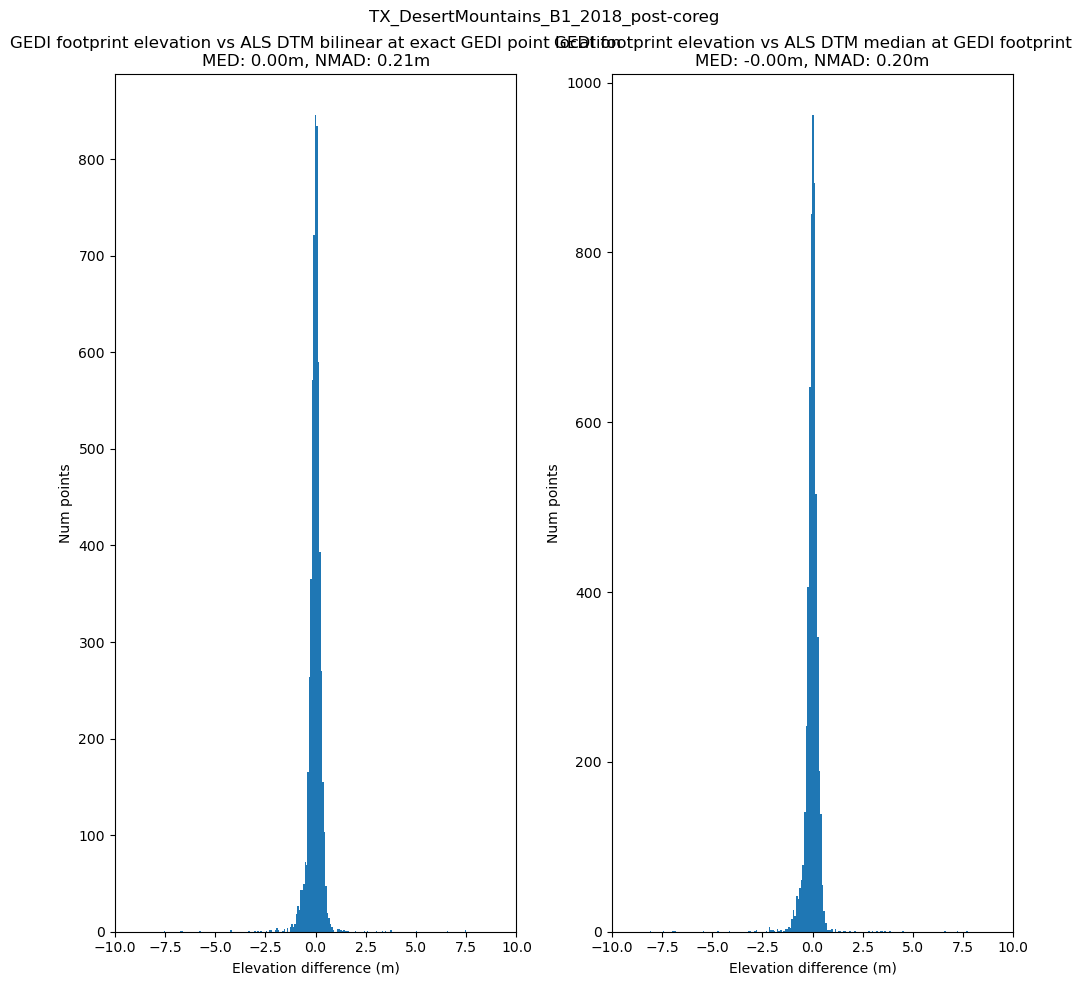

In [51]:
workunit_check(workunits[6])

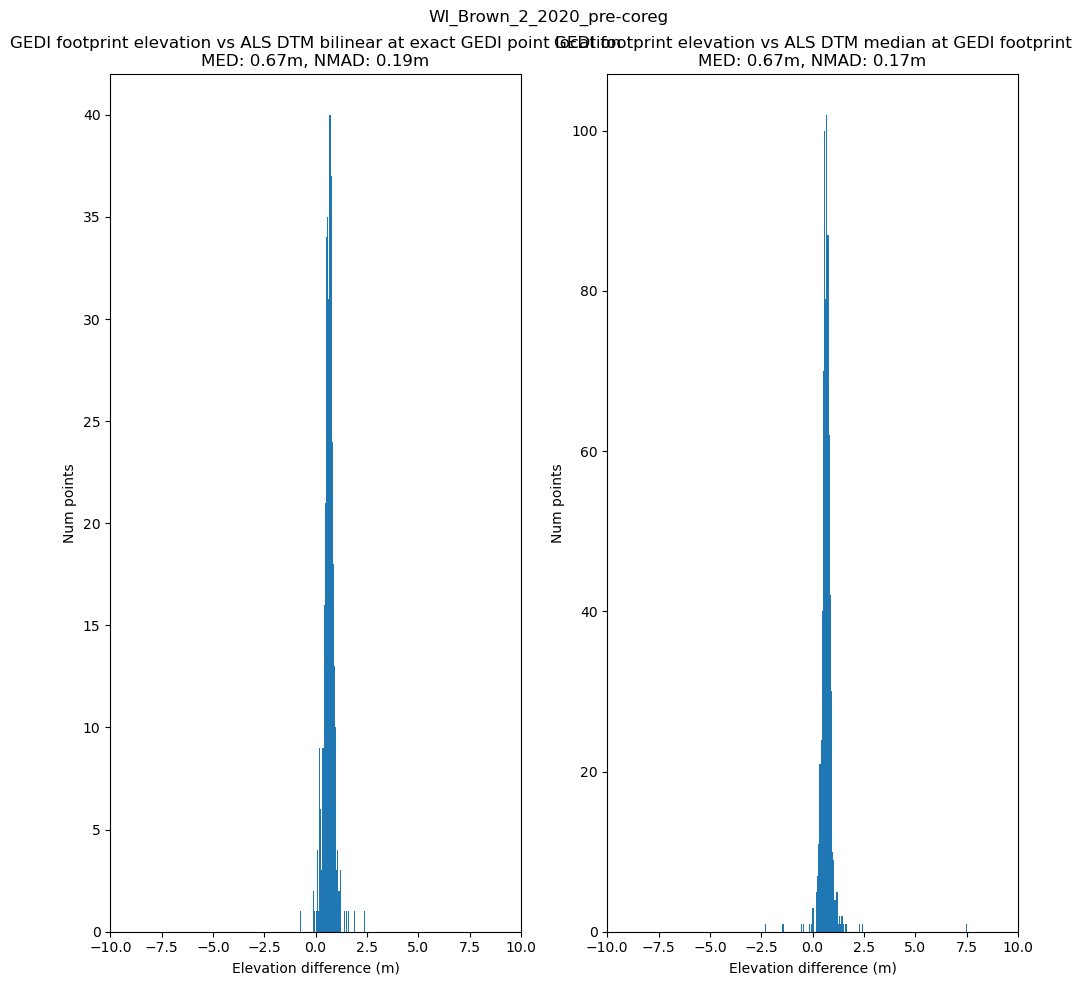

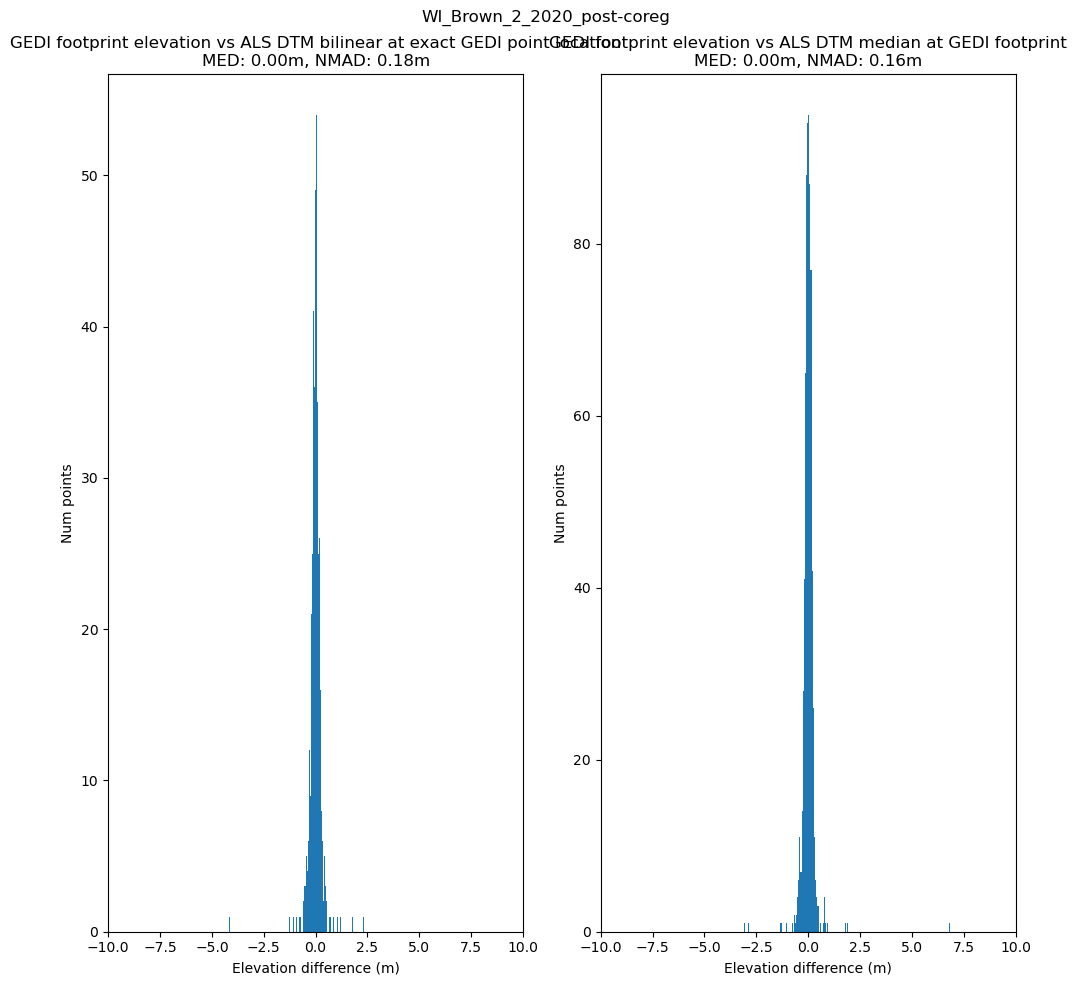

In [52]:
workunit_check(workunits[7])

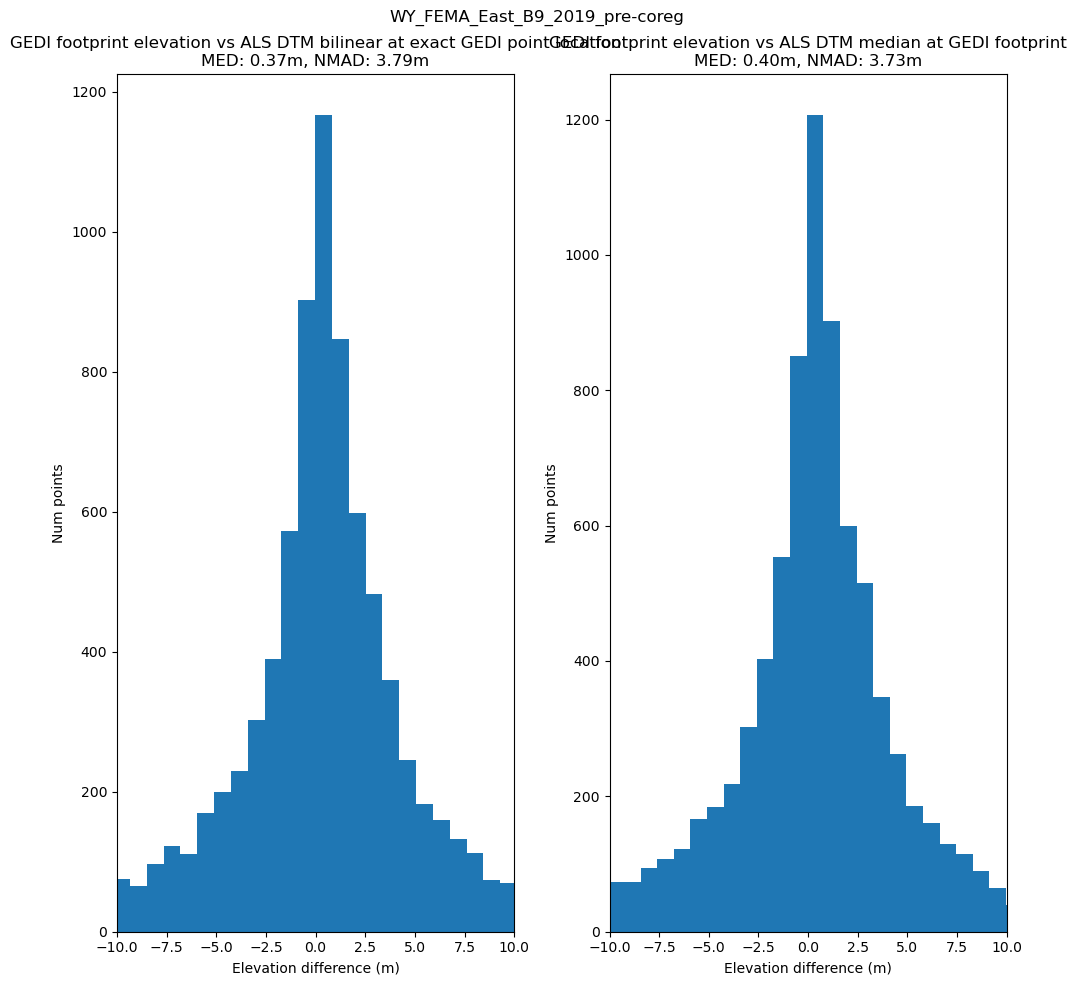

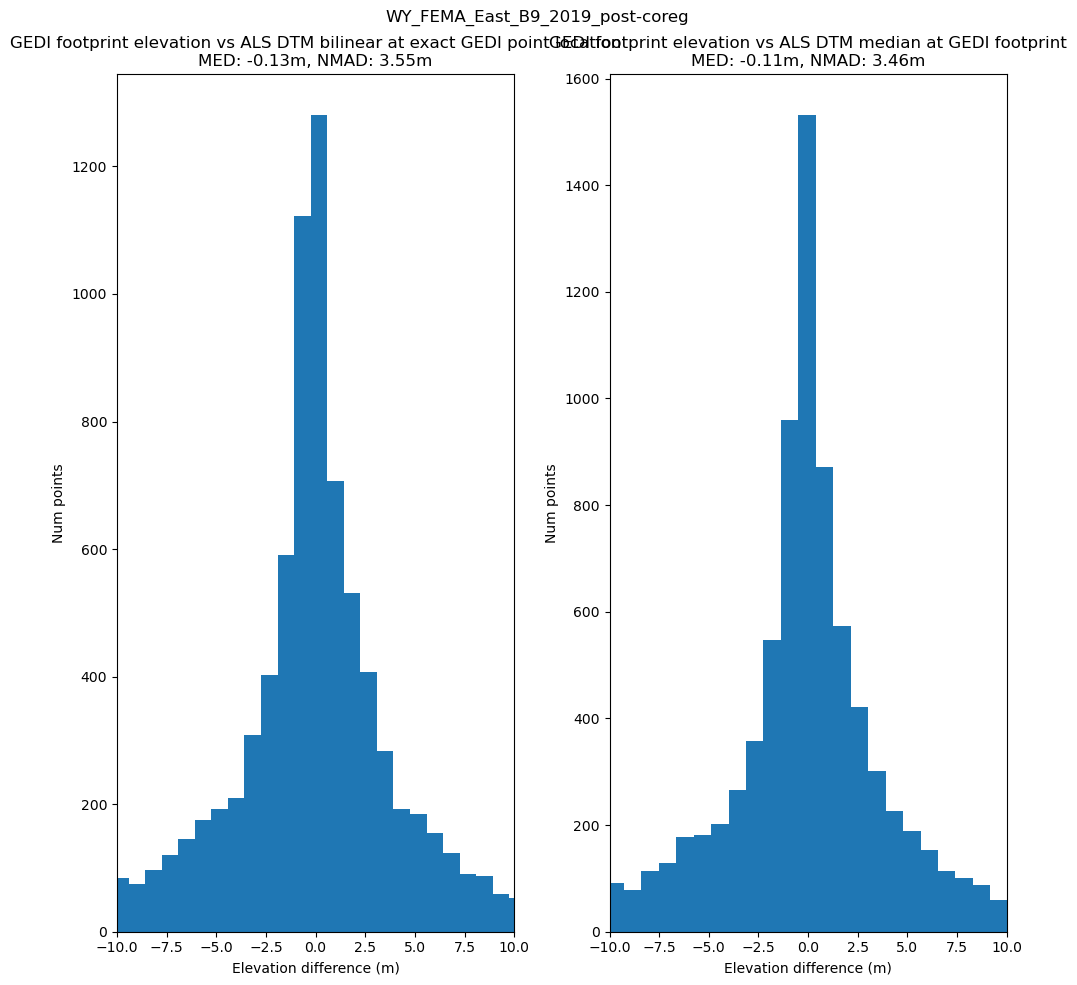

In [53]:
workunit_check(workunits[8])

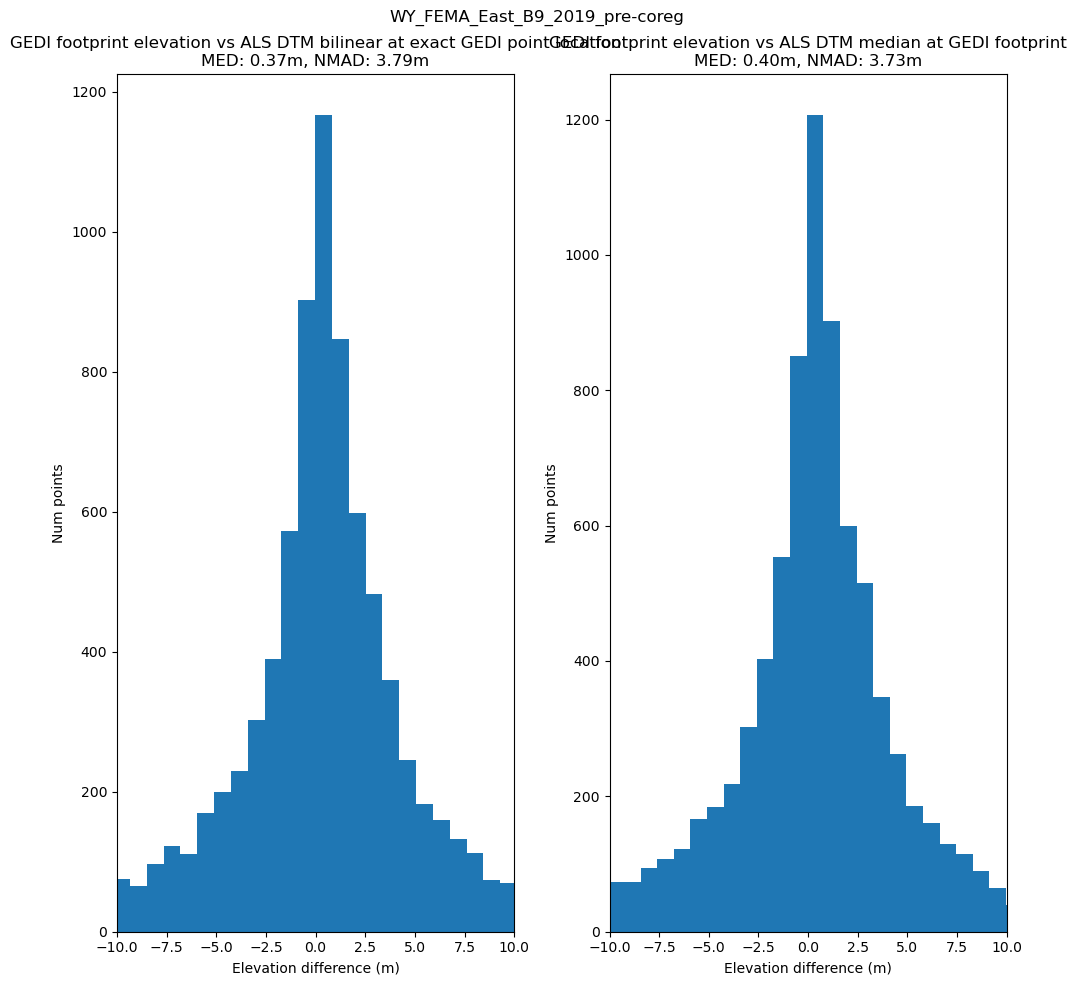

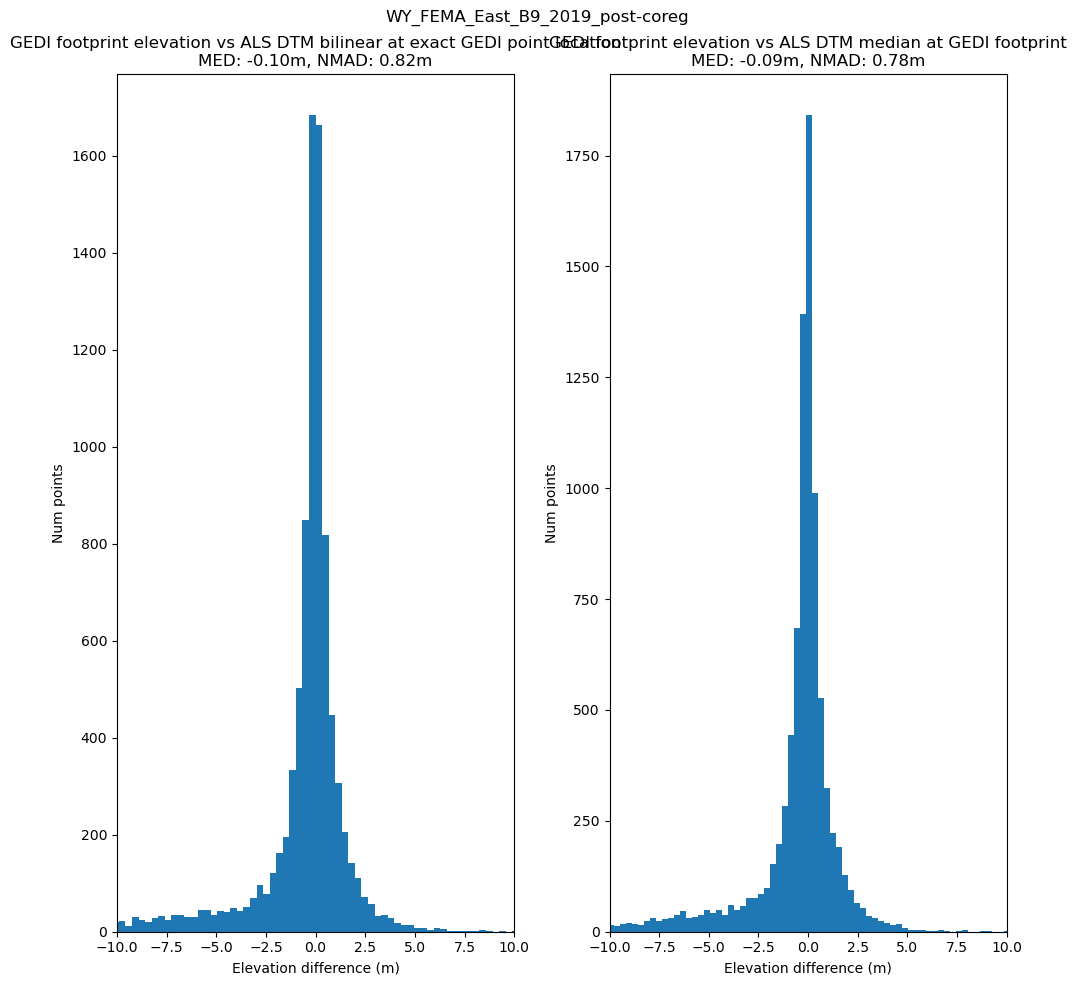

In [12]:
workunit_check(workunits[8])

In [13]:
def workunit_check_25m(workunit,clim=(-10,10)):
    lidar_dtm_fn = sorted(glob.glob(f'{workunit}*_processing/*DTM_fill_window_size_4_mos.tif'))[0] 
    gedi_gdf_postcoreg_fn = sorted(glob.glob(f'/panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_usgs_lpc_proc_total_bounds/delivery_version2/{workunit}*_processing_98_percentile/GEDI_aligned_product_*25m.gpkg'))[0]
                
    gedi_gdf_precoreg_fn = sorted(glob.glob(f'/panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_usgs_lpc_proc_total_bounds/delivery_version2/{workunit}*_processing_98_percentile/GEDI_original_product_*25m.gpkg'))[0]
    lidar_dtm_da = load_stv_product_local(lidar_dtm_fn)  
    perform_comparison(workunit,gedi_gdf_precoreg_fn,lidar_dtm_da,'pre-coreg',clim)

    perform_comparison(workunit,gedi_gdf_postcoreg_fn,lidar_dtm_da,'post-coreg',clim)

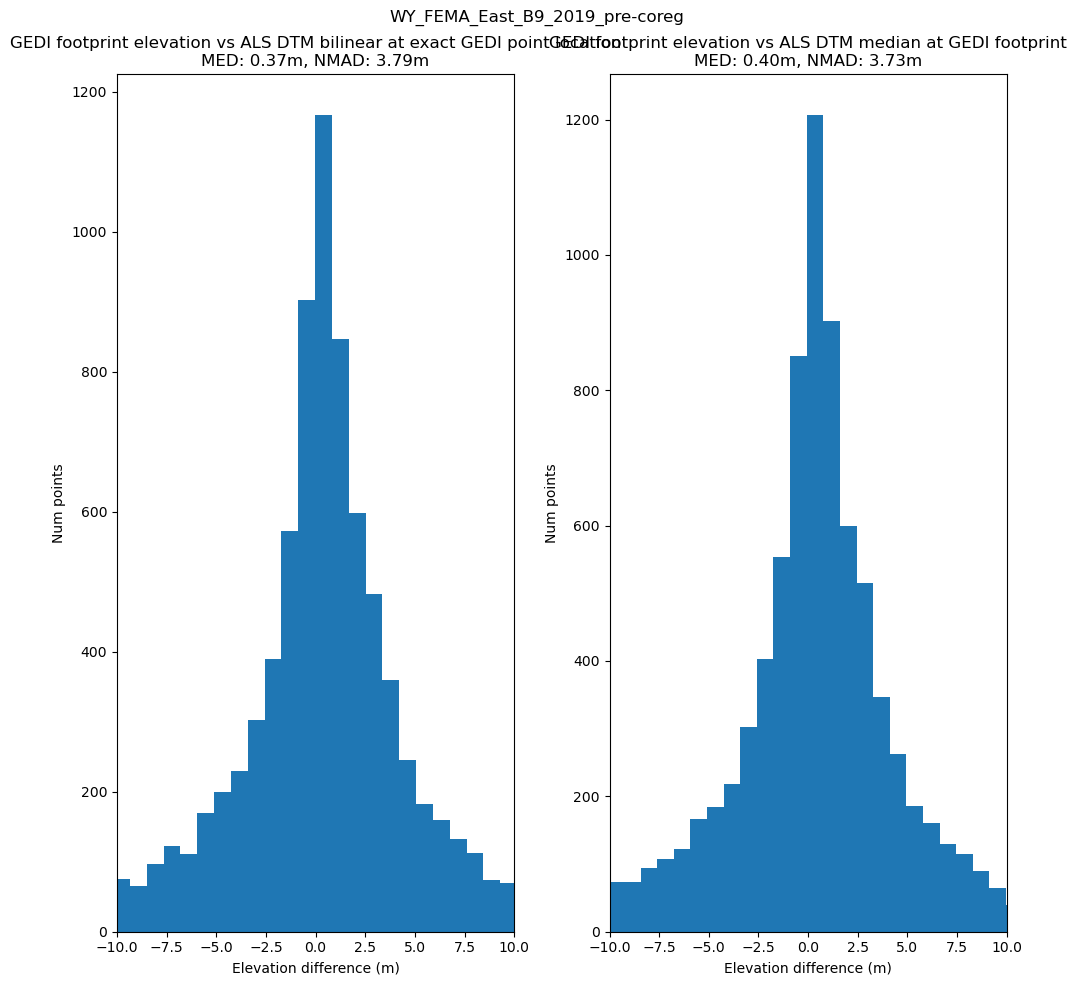

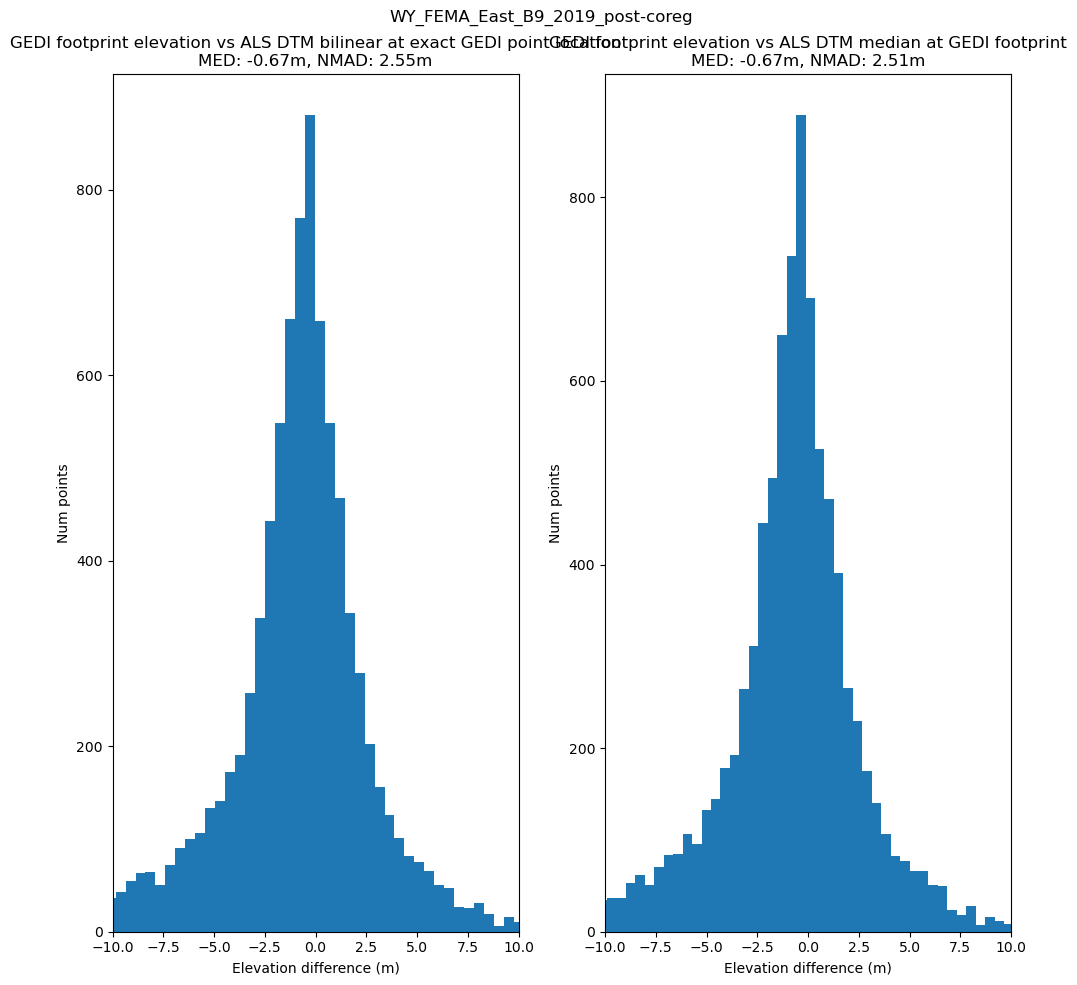

In [14]:
workunit_check_25m(workunits[8])

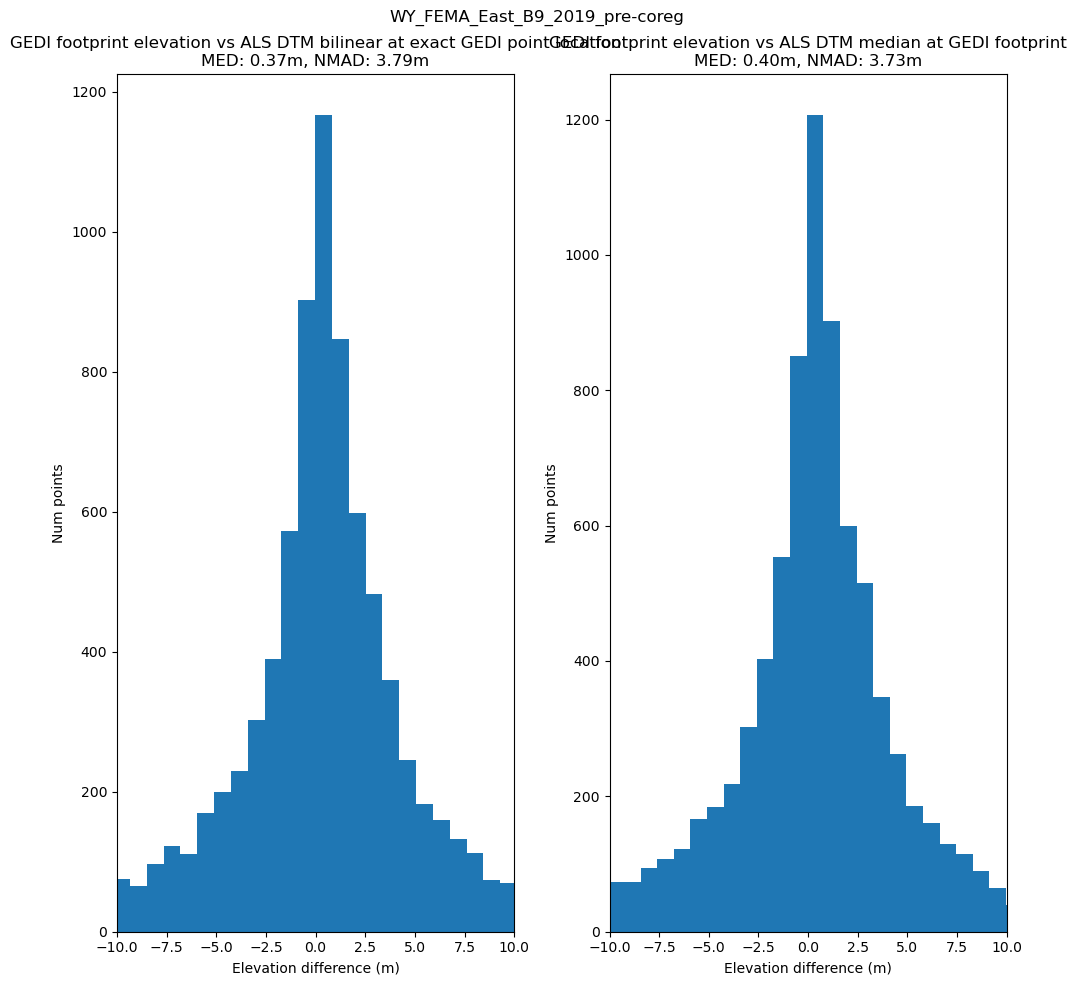

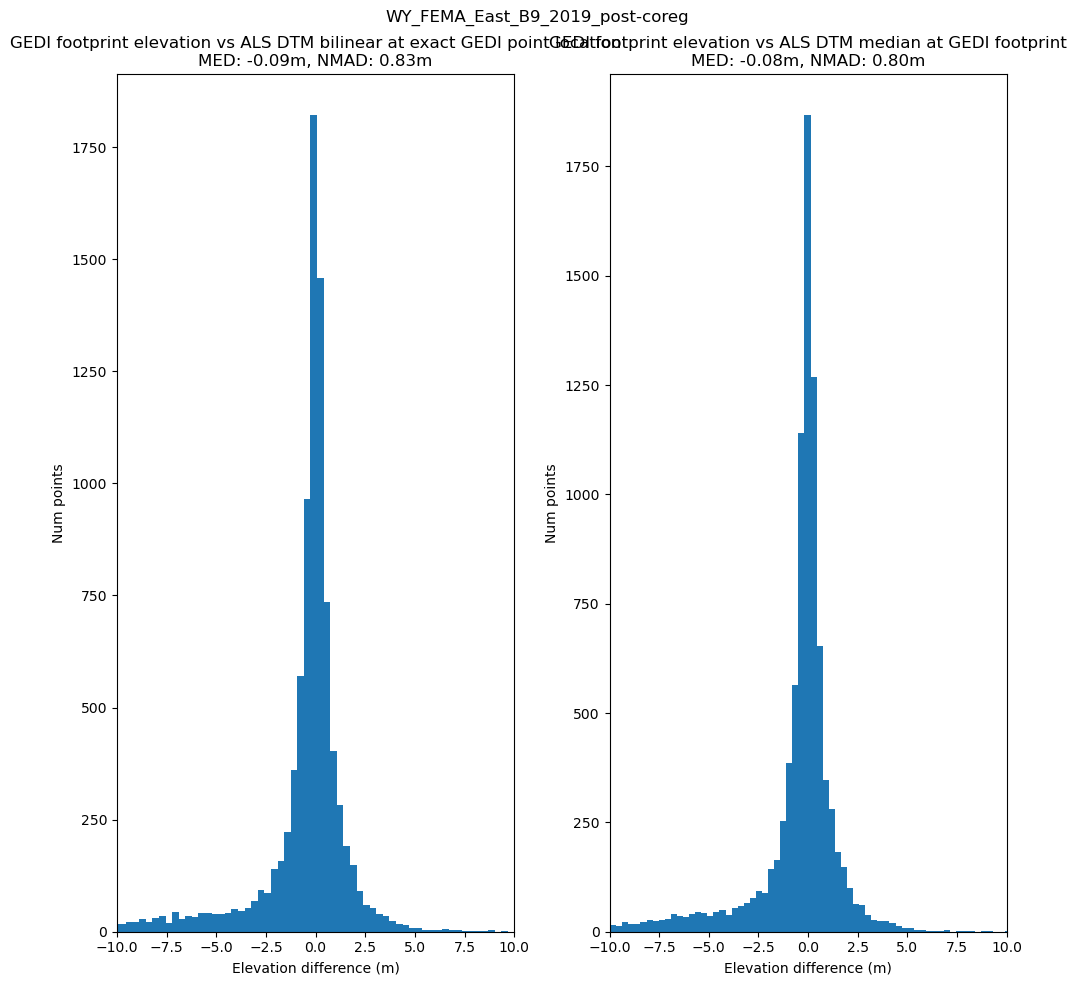

In [15]:
workunit_check_25m(workunits[8])